# Pipeline de Detecção de Crises Epilépticas — Notebook 3
## Análise de Resultados e Visualizações

**Dataset:** SeizeIT2 · **Autor:** Danilo Pedro da Silva Valério

---

# 📚 PARTE 0: Contextualização Completa do Pipeline

Este notebook apresenta os resultados de um sistema de detecção automática de crises epilépticas usando sinais de EEG (eletroencefalograma). Antes de visualizar os resultados, é essencial entender todo o processo.

---

## 🎯 Objetivo do Projeto

Desenvolver um **detector automático de crises epilépticas** que possa:
1. **Detectar** a maioria das crises (alta sensibilidade)
2. **Minimizar alarmes falsos** (baixa taxa de falsos positivos)
3. **Operar em tempo real** (viável clinicamente)

---

## 📊 1. Dataset: SeizeIT2

### O que é?
**SeizeIT2** é um dataset público de sinais de EEG de pacientes com epilepsia, contendo:
- **12 pacientes** (sub-001 a sub-012)
- **Gravações contínuas** de EEG (duração variável, ~4-74 horas por paciente)
- **Anotações manuais** de crises por especialistas

### Características do sinal:
- **Taxa de amostragem:** 250 Hz (250 amostras por segundo)
- **Canais:** Múltiplos eletrodos no couro cabeludo
- **Formato:** Arquivos EDF (European Data Format)

### Desafio principal:
**Desbalanceamento extremo:**
- Crises epilépticas: ~0.1-1% do tempo total
- Estado normal: ~99-99.9% do tempo
- Proporção típica: **1 janela de crise para cada 500+ janelas normais**

---

## 🔧 2. Pré-processamento (Notebook 1)

### 2.1 Download dos Dados

```python
# Bibliotecas utilizadas:
import mne           # Leitura de sinais EEG
import numpy as np   # Operações numéricas
import pandas as pd  # Manipulação de dados tabulares
```

**MNE-Python:** Biblioteca especializada em sinais neurofisiológicos. Permite:
- Ler arquivos EDF
- Aplicar filtros
- Extrair eventos anotados

---

### 2.2 Segmentação em Janelas

O sinal contínuo é dividido em **janelas temporais** para análise:

#### Configurações testadas:
| Nome | Tamanho | Overlap | Descrição |
|------|---------|---------|------------|
| **4s_50** | 4 segundos | 50% | Janela curta, alta resolução temporal |
| **5s_50** | 5 segundos | 50% | Balanceamento entre resolução e contexto |
| **6s_50** | 6 segundos | 50% | Janela longa, mais contexto |

**Overlap (sobreposição):**
- **50% de overlap** significa que cada janela compartilha metade com a anterior
- Exemplo com janelas de 4s:
  - Janela 1: 0-4s
  - Janela 2: 2-6s (sobrepõe 2s com janela 1)
  - Janela 3: 4-8s

**Por que usar overlap?**
- Evita perder eventos que ocorrem na fronteira das janelas
- Aumenta a quantidade de dados para treinamento
- Melhora a detecção contínua

---

### 2.3 Filtragem do Sinal

Aplicação de **filtro passa-banda** para remover ruídos:

```python
# Frequências de interesse:
f_min = 0.5 Hz   # Remove drift de linha de base
f_max = 50 Hz    # Remove ruído de alta frequência
```

**Bandas de frequência do EEG:**
- **Delta (0.5-4 Hz):** Sono profundo
- **Theta (4-8 Hz):** Sonolência, meditação
- **Alpha (8-13 Hz):** Relaxamento, olhos fechados
- **Beta (13-30 Hz):** Estado de alerta, concentração
- **Gamma (30-50 Hz):** Processamento cognitivo complexo

---

### 2.4 Extração de Features (FS-A)

**Feature Set A (FS-A)** extrai características espectrais usando **GWST** (Generalized Wavelet Scalogram Transform):

#### Para cada banda de frequência:
1. **Energia (L1):** Magnitude média dos coeficientes wavelet
   - Captura intensidade da atividade naquela banda
   
2. **Entropia:** Medida de desordem/complexidade do sinal
   - Crises epilépticas têm padrões específicos de entropia

**Total de features por janela:**
```
5 bandas × 2 métricas × n_canais = 10 × n_canais features
```

---

### 2.5 Rotulação

Cada janela recebe um rótulo:
- **1 (seizure):** Se contém ≥ 1 amostra de crise
- **0 (non-seizure):** Se é completamente normal

**Resultado:**
```
X: matriz de features (n_janelas × n_features)
y: vetor de rótulos (n_janelas,)
```

---

## 🤖 3. Treinamento (Notebook 2)

### 3.1 Validação LOSO

**LOSO = Leave-One-Subject-Out**

Estratégia de validação cruzada específica para dados médicos:

```python
Para cada paciente (sub-001 a sub-012):
    TREINO: usar dados de 11 pacientes
    TESTE:  usar dados de 1 paciente (deixado de fora)
```

**Por que LOSO?**
- **Simula cenário real:** Modelo treinado em pacientes conhecidos, testado em novo paciente
- **Evita data leakage:** Dados do mesmo paciente nunca aparecem em treino e teste
- **Validação rigorosa:** Se funciona em LOSO, tende a funcionar em novos pacientes

---

### 3.2 Undersampling (Balanceamento de Classes)

**Problema:** Dataset desbalanceado (~1:500)

**Solução:** Reduzir quantidade de janelas normais no treino

#### Ratios testados:
- **1:3** → Para cada janela de crise, manter 3 janelas normais
- **1:5** → Para cada janela de crise, manter 5 janelas normais

**Método:** STRIDE (passo uniforme)
```python
# Exemplo com 1000 janelas normais e 10 crises:
# Ratio 1:3 → quer 30 normais
stride = 1000 // 30 = 33
# Seleciona índices: 0, 33, 66, 99, ...
```

**Vantagem do STRIDE sobre amostragem aleatória:**
- Preserva distribuição temporal
- Não concentra em períodos específicos
- Mais representativo do sinal completo

---

### 3.3 Modelos de Machine Learning

#### **3.3.1 XGBoost (Extreme Gradient Boosting)**

**Tipo:** Ensemble de árvores de decisão

**Como funciona:**
1. Cria árvore inicial (fraca)
2. Identifica erros da árvore anterior
3. Treina nova árvore focada em corrigir esses erros
4. Repete N vezes (boosting)
5. Combina todas as árvores (ensemble)

**Hiperparâmetros:**
```python
n_estimators=50          # Número de árvores
max_depth=4              # Profundidade máxima (evita overfitting)
learning_rate=0.1        # Taxa de aprendizado (passo do gradiente)
scale_pos_weight         # Peso para classe minoritária
subsample=0.5            # Usa 50% dos dados em cada árvore
colsample_bytree=0.8     # Usa 80% das features em cada árvore
```

**Vantagens:**
- Lida bem com dados desbalanceados
- Rápido para treinar
- Não precisa normalização

---

#### **3.3.2 SVM (Support Vector Machine)**

**Tipo:** Classificador baseado em margem máxima

**Como funciona:**
1. Mapeia dados para espaço de alta dimensão (kernel RBF)
2. Encontra hiperplano que separa classes com margem máxima
3. Usa apenas pontos na fronteira (support vectors)

**Kernel RBF (Radial Basis Function):**
```python
K(x, x') = exp(-γ ||x - x'||²)
```
- Permite separação não-linear
- γ controla influência de cada ponto

**Pré-processamento SVM:**
```python
# 1. Seleção de features (mutual information)
selector = SelectKBest(mutual_info_classif, k=150)

# 2. Normalização (StandardScaler)
scaler = StandardScaler()  # (X - μ) / σ
```

**Por que normalizar?**
- SVM é sensível à escala das features
- Features com valores grandes dominam o kernel
- Normalização garante peso igual para todas

---

#### **3.3.3 Random Forest**

**Tipo:** Ensemble de árvores de decisão

**Como funciona:**
1. Cria N árvores independentes
2. Cada árvore usa:
   - Amostra aleatória dos dados (bootstrap)
   - Subconjunto aleatório de features
3. Predição final: votação majoritária

**Hiperparâmetros:**
```python
n_estimators=200            # Número de árvores
max_features='sqrt'         # √n_features por árvore
max_depth=None              # Sem limite de profundidade
min_samples_leaf=2          # Mínimo de amostras por folha
class_weight='balanced_subsample'  # Balanceia classes
```

**Diferença XGBoost vs Random Forest:**
- **XGBoost:** Árvores sequenciais (corrigem erros anteriores)
- **Random Forest:** Árvores paralelas (independentes)

---

## 3.4 Otimização de Threshold

### 🔰 O que é Threshold?

Modelos de classificação não retornam diretamente **0 ou 1**.  
Eles retornam uma **probabilidade**:

    model.predict_proba(X)  # ex: [0.3, 0.7]

Ou seja:
- 30% chance de ser classe 0  
- 70% chance de ser classe 1  

O **threshold (limiar)** é o valor usado para decidir a classe final:

    if prob >= threshold:
        classe = 1
    else:
        classe = 0

👉 Por padrão, usamos `0.5`, mas isso nem sempre é ideal.

---

### ⚙️ Intuição rápida

- **Threshold baixo (ex: 0.3)**  
  → mais casos classificados como positivos  
  → ↑ recall (detecta mais)  
  → ↑ falsos positivos  

- **Threshold alto (ex: 0.7)**  
  → mais conservador  
  → ↓ falsos positivos  
  → ↓ recall  

---

### ⚠️ Problema do 0.5

Em dados **desbalanceados**, o threshold padrão pode ser ruim.

Exemplo:
- Fraude, doença, falha (casos raros)
- O modelo tende a errar justamente o que mais importa

---

### ✅ Solução: otimizar o threshold

Em vez de usar 0.5, buscamos o valor que maximiza uma métrica (ex: **Sensitivity**).


---

### 🧪 Implementação (forma correta)

Evite usar o **treino** — use um conjunto de **validação**:

    import numpy as np
    from sklearn.metrics import f1_score

    # Probabilidades na validação
    y_score_val = model.predict_proba(X_val)[:, 1]

    best_thr = 0.5
    best_f1 = 0.0

    for thr in np.linspace(0.01, 0.99, 200):
        y_pred_thr = (y_score_val >= thr).astype(int)
        f1 = f1_score(y_val, y_pred_thr)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    print(f"Best threshold: {best_thr:.3f}")

---

### 🚀 Aplicando no teste

    y_score_test = model.predict_proba(X_test)[:, 1]
    y_pred = (y_score_test >= best_thr).astype(int)

---

### 🧠 Resumo

- O modelo prevê **probabilidades**
- O threshold transforma isso em **decisão**
- Ajustar o threshold = **controlar o trade-off entre erros**

---

### 📌 Próximos passos (opcional)

- Usar Precision-Recall Curve  
- Otimizar com base em custo de erro (ex: falso negativo mais caro)

## 📏 4. Métricas de Avaliação

### 4.1 Matriz de Confusão

```
                    Predição
                 Normal  |  Crise
            ----------------------
Real Normal |  TN     |   FP
            ----------------------
Real Crise  |  FN     |   TP
```

- **TP (True Positive):** Crise detectada corretamente
- **TN (True Negative):** Normal identificado corretamente
- **FP (False Positive):** Normal classificado como crise (alarme falso)
- **FN (False Negative):** Crise perdida (CRÍTICO!)

---

### 4.2 Sensitivity (Sensibilidade / Recall)

```python
Sensitivity = TP / (TP + FN)
```

**Pergunta:** "Das crises REAIS, quantas % foram detectadas?"

**Exemplo:**
- 10 crises reais no dataset
- 7 foram detectadas (TP=7)
- 3 foram perdidas (FN=3)
- Sensitivity = 7/10 = 0.70 (70%)

**Meta clínica:** ≥ 0.80 (80%)

**Por que é crítica?**
- Perder uma crise pode ser fatal
- Prioridade máxima em aplicações médicas

---

### 4.3 Specificity (Especificidade)

```python
Specificity = TN / (TN + FP)
```

**Pergunta:** "Das janelas NORMAIS, quantas % foram corretamente identificadas?"

**Exemplo:**
- 1000 janelas normais
- 850 identificadas como normais (TN=850)
- 150 classificadas como crise (FP=150)
- Specificity = 850/1000 = 0.85 (85%)

**Relação com FAR:**
- Specificity alta → Menos falsos positivos
- Specificity baixa → Muitos alarmes falsos

---

### 4.4 Precision (Precisão)

```python
Precision = TP / (TP + FP)
```

**Pergunta:** "Quando o modelo prevê crise, qual a chance de estar certo?"

**Exemplo:**
- Modelo prevê 100 janelas como crise
- 10 são realmente crises (TP=10)
- 90 são alarmes falsos (FP=90)
- Precision = 10/100 = 0.10 (10%)

**Em datasets desbalanceados:**
- Precision tende a ser MUITO BAIXA
- Mesmo modelos bons têm precision < 0.05
- **NÃO é indicador de qualidade aqui!**

---

### 4.5 F1-Score

```python
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

**O que é:** Média harmônica entre Precision e Recall

**Problema em dados desbalanceados:**
```
Recall = 0.80  (bom)
Precision = 0.02  (baixo devido ao desbalanceamento)

F1 = 2 × (0.80 × 0.02) / (0.80 + 0.02)
   = 0.032 / 0.82
   = 0.039  (parece péssimo!)
```

**Conclusão:** F1 é enganoso em epilepsia. Devemos utilizar outras métricas!

---

### 4.6 FAR (False Alarm Rate)

```python
FAR = número_de_bursts_falsos / horas_totais
```

**O que é:** Alarmes falsos por hora

**Cálculo de bursts:**
```python
# Agrupar falsos positivos consecutivos em um único burst:
bursts = 0
in_burst = False

for fp in false_positives:
    if fp and not in_burst:
        bursts += 1
        in_burst = True
    elif not fp:
        in_burst = False
```

**Exemplo:**
```
Predições: [0,0,1,1,1,0,0,1,0,0]
Reais:     [0,0,0,0,0,0,0,0,0,0]

FP individuais: 4 (índices 2,3,4,7)
Bursts: 2 (um em 2-4, outro em 7)
```

**Meta clínica:** < 5/h (1 alarme a cada 12 minutos)

**Por que é importante?**
- FAR > 10/h → Fadiga de alarme (médicos ignoram)
- FAR < 5/h → Aceitável clinicamente

---

### 4.7 AUC-PR (Area Under Precision-Recall Curve)

**O que é:** Área sob a curva Precision-Recall

**Como calcular:**
1. Para cada threshold possível (0.0 a 1.0)
2. Calcula Precision e Recall
3. Plota curva Precision(y) vs Recall(x)
4. Calcula área sob a curva

**Interpretação:**
- **0.0 a 1.0** (quanto maior, melhor)
- **Baseline aleatório:** proporção de positivos no dataset
- Em epilepsia (1:500): baseline ≈ 0.002

**Vantagens:**
- Funciona bem com desbalanceamento
- Considera todos os thresholds
- Melhor que F1 para comparar modelos

**Meta:** > 0.10 já é bom em detecção de crises

---

## 🔬 5. Duas Abordagens de Avaliação

### **Baseline: Comparação Controlada**

**Objetivo:** Comparar diferentes configurações em condições iguais

**Método:**
- **Treino:** Com undersampling (ratio 1:3 ou 1:5)
- **Teste:** Com undersampling (mesmo ratio do treino)

**Métricas principais:**
- F1-Score
- Precision
- AUC-PR

**Vantagens:**
- Métricas comparáveis
- F1 interpretável
- Facilita análise estatística

**Limitação:**
- NÃO reflete realidade clínica
- FAR artificialmente baixo

---

### **V2: Avaliação Clínica Realista**

**Objetivo:** Validar viabilidade no mundo real

**Método:**
- **Treino:** Com undersampling (ratio 1:3 ou 1:5)
- **Teste:** Paciente INTEIRO (sem undersampling)

**Métricas principais:**
- Sensitivity
- FAR (false alarm rate)
- AUC-PR

**Vantagens:**
- Simula cenário clínico real
- FAR realista
- Valida viabilidade prática

**Limitação:**
- F1 muito baixo (esperado)
- Precision baixa (esperado)

---

### Comparação:

| Aspecto | Baseline | V2 (Clínica) |
|---------|----------|-------------|
| **Teste** | Com ratio | Paciente inteiro |
| **F1** | 0.40-0.70 | 0.01-0.10 |
| **Precision** | 0.30-0.80 | 0.01-0.05 |
| **FAR** | 5-20/h | 50-150/h |
| **Uso** | Comparar configs | Validar viabilidade |

---

## 📈 6. Análise de Overfitting

### O que é Overfitting?

**Overfitting** ocorre quando o modelo:
- **Memoriza** os dados de treino
- **Não generaliza** para novos dados

**Exemplo:**
```
Treino: Acurácia = 99%
Teste:  Acurácia = 60%

→ Modelo decorou padrões específicos do treino
→ Não aprendeu padrões gerais
```

### Como detectar?

**Em modelos com curvas de aprendizado (XGBoost):**
```python
eval_set = [(X_train, y_train), (X_val, y_val)]
model.fit(X_train, y_train, 
          eval_set=eval_set,
          verbose=False)

results = model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']
```

**Sinais de overfitting:**
1. **Loss de treino diminui** continuamente
2. **Loss de validação aumenta** após certo ponto
3. **Gap crescente** entre treino e validação

```
Loss
  |
  |     treino ──────────────
  |                        ╲
  |                         ╲
  |            validação     ╲
  |     ─────╱               ╲
  |         ╱                 ╲
  |        ╱                   ╲
  |_______╱_____________________╲____> Época
          ↑
    Ponto ótimo
```

### Prevenção de Overfitting:

**XGBoost:**
- `max_depth=4` (limita complexidade)
- `subsample=0.5` (amostragem aleatória)
- `colsample_bytree=0.8` (subset de features)
- Early stopping (para quando validação piora)

**Random Forest:**
- `max_features='sqrt'` (subset aleatório)
- `min_samples_leaf=2` (evita folhas muito específicas)
- Bootstrap (amostragem com reposição)

**SVM:**
- Regularização implícita (margem máxima)
- Kernel RBF com γ controlado

---

## 🎯 7. Critérios de Sucesso Clínico

Para um detector ser **viável clinicamente**, deve atingir:

### Critérios Mínimos:
1. **Sensitivity ≥ 0.80** (80% de detecção)
2. **FAR < 5/h** (máximo 5 alarmes falsos por hora)
3. **Delay < 30s** (detecta até 30s após início da crise)

### Critérios Desejáveis:
1. **Sensitivity ≥ 0.90** (90% de detecção)
2. **FAR < 1/h** (máximo 1 alarme falso por hora)
3. **Delay < 10s** (detecta até 10s após início)

### Por que esses valores?

**Sensitivity:**
- 80% → Perde 1 em cada 5 crises (aceitável)
- 90% → Perde 1 em cada 10 crises (ideal)
- < 80% → Muito arriscado clinicamente

**FAR:**
- 5/h → 1 alarme a cada 12 minutos (tolerável)
- 1/h → 1 alarme por hora (confortável)
- > 10/h → Fadiga de alarme (médicos ignoram)

**Delay:**
- < 10s → Permite intervenção precoce
- < 30s → Ainda útil para muitas aplicações
- > 60s → Benefício clínico reduzido

---

Agora vamos visualizar os resultados dos experimentos!

---

# 📊 PARTE 1: Carregamento e Preparação dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [2]:
# Carregar dados
DATA_DIR = Path('./data')

# Resultados baseline (teste com ratio)
df_baseline = pd.read_csv(DATA_DIR / 'results_baseline_all.csv')
ranking_baseline = pd.read_csv(DATA_DIR / 'ranking_baseline.csv')

# Resultados v2 (teste no paciente inteiro)
df_v2 = pd.read_csv(DATA_DIR / 'results_v2_all.csv')
ranking_v2 = pd.read_csv(DATA_DIR / 'ranking_v2.csv')

# Comparação
comparison = pd.read_csv(DATA_DIR / 'comparison_baseline_vs_v2.csv')

print(f"✅ Dados carregados:")
print(f"   Baseline: {len(df_baseline)} resultados (12 pacientes × 18 configs)")
print(f"   V2 (clínica): {len(df_v2)} resultados")
print(f"   Rankings: {len(ranking_baseline)} configurações")

✅ Dados carregados:
   Baseline: 216 resultados (12 pacientes × 18 configs)
   V2 (clínica): 216 resultados
   Rankings: 18 configurações


# 📈 PARTE 2: Visualizações - Baseline (Comparação Controlada)

## 2.1 Ranking Geral - Top 10 Configurações

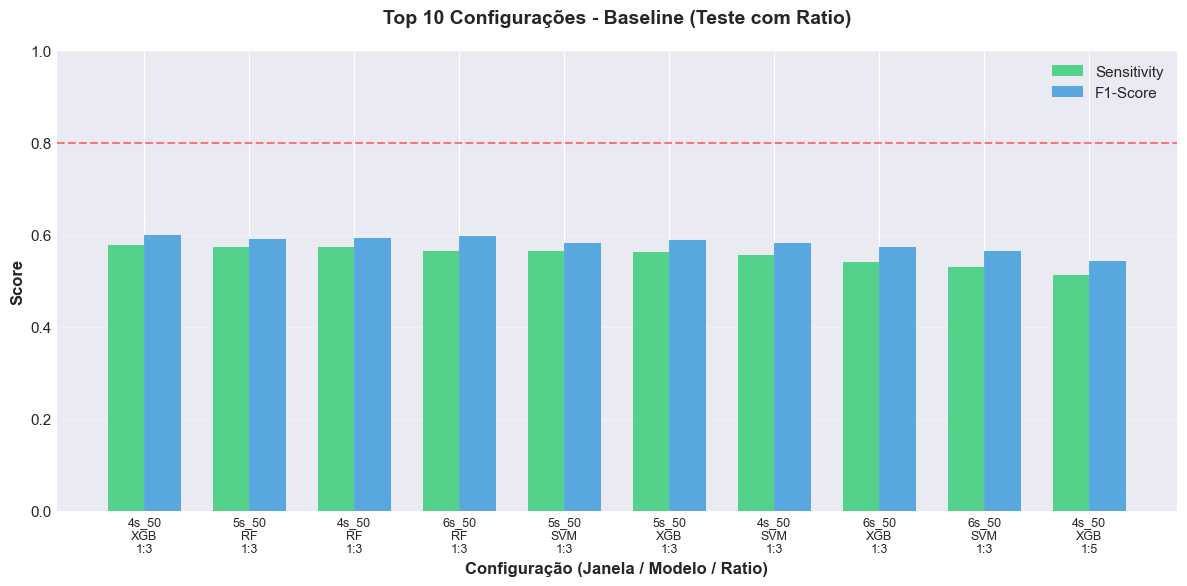


📊 Top 3 Configurações (Baseline):
Janela Modelo Ratio  sensitivity       f1  far_per_hour
 4s_50    XGB   1:3     0.577975 0.599692    118.584503
 5s_50     RF   1:3     0.573872 0.589899     99.477346
 4s_50     RF   1:3     0.572955 0.592539    123.438281


In [3]:
# Top 10 configurações (baseline)
top10_baseline = ranking_baseline.head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top10_baseline))
width = 0.35

# Barras
bars1 = ax.bar(x - width/2, top10_baseline['sensitivity'], width, 
               label='Sensitivity', alpha=0.8, color='#2ecc71')
bars2 = ax.bar(x + width/2, top10_baseline['f1'], width, 
               label='F1-Score', alpha=0.8, color='#3498db')

# Rótulos
labels = [f"{row['Janela']}\n{row['Modelo']}\n{row['Ratio']}" 
          for _, row in top10_baseline.iterrows()]

ax.set_xlabel('Configuração (Janela / Modelo / Ratio)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Configurações - Baseline (Teste com Ratio)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Linha de referência
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, 
           label='Meta Clínica (80%)')

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_baseline_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Top 3 Configurações (Baseline):")
print(top10_baseline[['Janela', 'Modelo', 'Ratio', 'sensitivity', 'f1', 'far_per_hour']].head(3).to_string(index=False))

## 2.2 Comparação entre Modelos (Baseline)

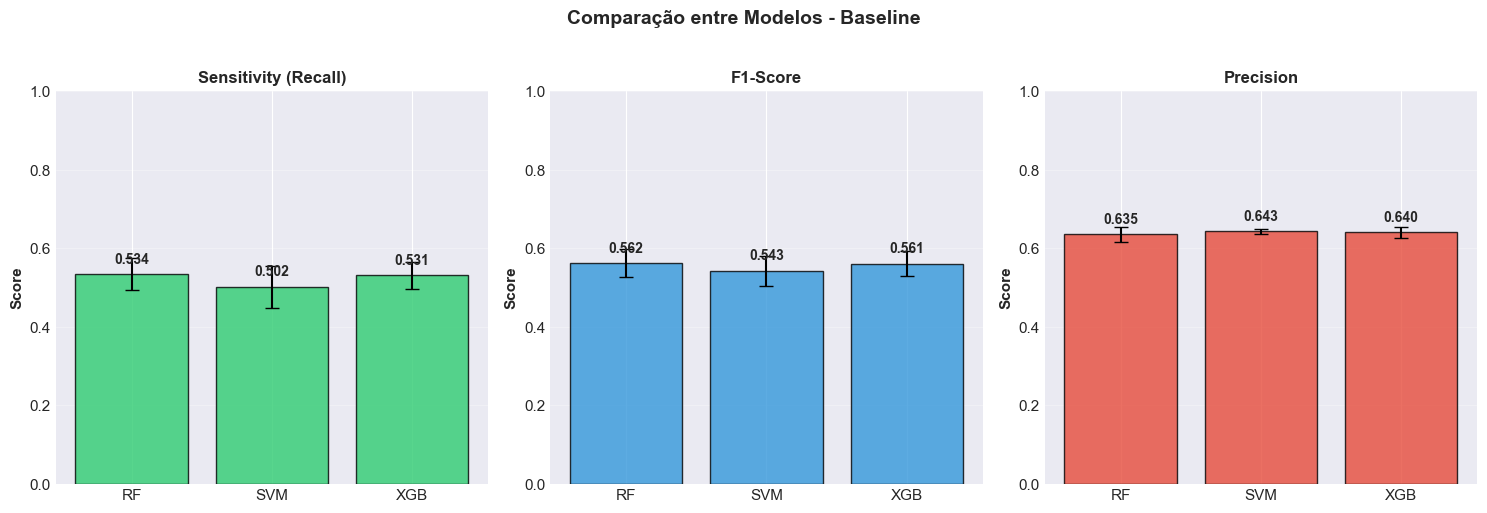


📊 Estatísticas por Modelo (Baseline):
       sensitivity            f1        precision       
              mean    std   mean    std      mean    std
Modelo                                                  
RF           0.534  0.041  0.562  0.035     0.635  0.020
SVM          0.502  0.054  0.543  0.038     0.643  0.006
XGB          0.531  0.035  0.561  0.031     0.640  0.013


In [4]:
# Agrupar por modelo
modelo_stats = ranking_baseline.groupby('Modelo').agg({
    'sensitivity': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std']
}).round(3)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['sensitivity', 'f1', 'precision']
titles = ['Sensitivity (Recall)', 'F1-Score', 'Precision']
colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx]
    
    means = modelo_stats[metric]['mean']
    stds = modelo_stats[metric]['std']
    
    bars = ax.bar(means.index, means.values, yerr=stds.values, 
                  capsize=5, alpha=0.8, color=color, edgecolor='black')
    
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Valores nas barras
    for bar, val in zip(bars, means.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparação entre Modelos - Baseline', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_baseline_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Estatísticas por Modelo (Baseline):")
print(modelo_stats)

## 2.3 Impacto do Ratio de Undersampling (Baseline)

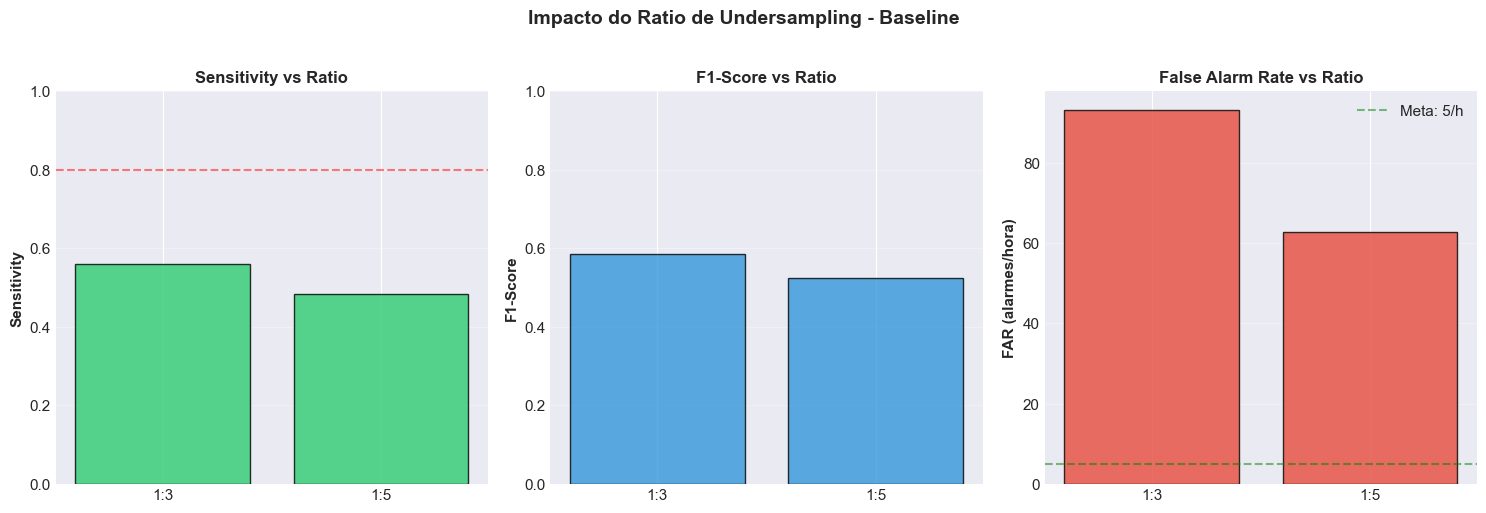


📊 Impacto do Ratio (Baseline):
       sensitivity     f1  far_per_hour
Ratio                                  
1:3          0.560  0.586        93.175
1:5          0.484  0.525        62.732


In [6]:
# Agrupar por ratio
ratio_stats = ranking_baseline.groupby('Ratio').agg({
    'sensitivity': 'mean',
    'f1': 'mean',
    'far_per_hour': 'mean'
}).round(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sensitivity
axes[0].bar(ratio_stats.index, ratio_stats['sensitivity'], 
            alpha=0.8, color='#2ecc71', edgecolor='black')
axes[0].set_ylabel('Sensitivity', fontsize=11, fontweight='bold')
axes[0].set_title('Sensitivity vs Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.80, color='red', linestyle='--', alpha=0.5)

# F1
axes[1].bar(ratio_stats.index, ratio_stats['f1'], 
            alpha=0.8, color='#3498db', edgecolor='black')
axes[1].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[1].set_title('F1-Score vs Ratio', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)
axes[1].grid(axis='y', alpha=0.3)

# FAR
axes[2].bar(ratio_stats.index, ratio_stats['far_per_hour'], 
            alpha=0.8, color='#e74c3c', edgecolor='black')
axes[2].set_ylabel('FAR (alarmes/hora)', fontsize=11, fontweight='bold')
axes[2].set_title('False Alarm Rate vs Ratio', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
axes[2].axhline(y=5, color='green', linestyle='--', alpha=0.5, 
                label='Meta: 5/h')
axes[2].legend()

plt.suptitle('Impacto do Ratio de Undersampling - Baseline', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_baseline_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Impacto do Ratio (Baseline):")
print(ratio_stats)

# 📈 PARTE 3: Visualizações - V2 (Avaliação Clínica)

## 3.1 Ranking Geral - Top 10 Configurações (V2)

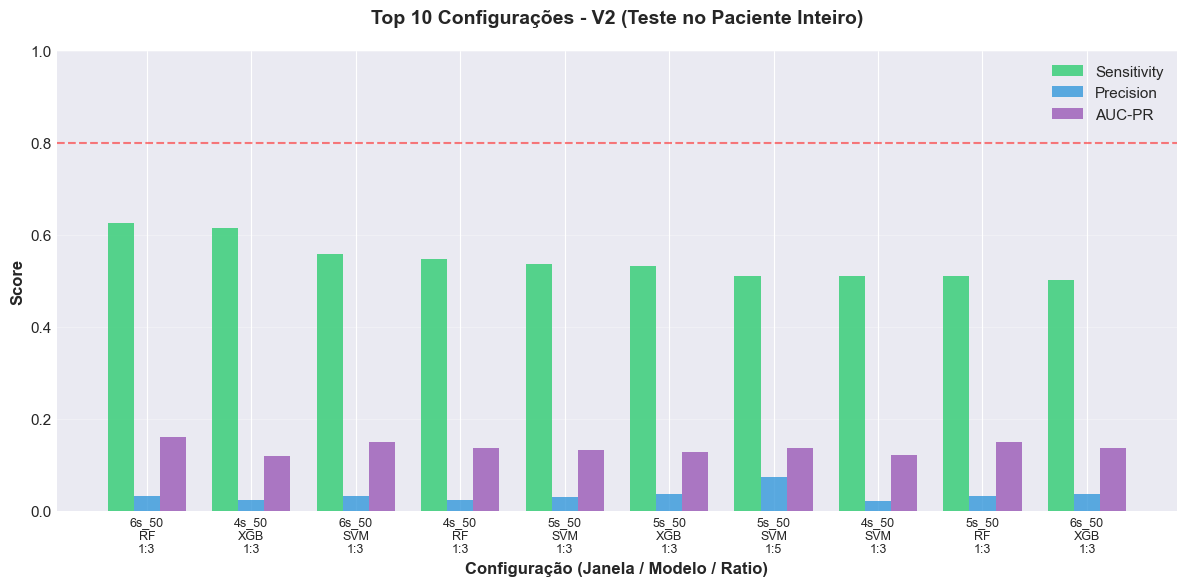


📊 Top 3 Configurações (V2 - Clínica):
Janela Modelo Ratio  sensitivity  precision  far_per_hour
 6s_50     RF   1:3     0.626389   0.032994      9.748436
 4s_50    XGB   1:3     0.615278   0.024029     12.253852
 6s_50    SVM   1:3     0.558333   0.033171      7.884449


In [7]:
# Top 10 configurações (v2)
top10_v2 = ranking_v2.head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top10_v2))
width = 0.25

# Barras
bars1 = ax.bar(x - width, top10_v2['sensitivity'], width, 
               label='Sensitivity', alpha=0.8, color='#2ecc71')
bars2 = ax.bar(x, top10_v2['precision'], width, 
               label='Precision', alpha=0.8, color='#3498db')
bars3 = ax.bar(x + width, top10_v2['auc_pr'], width, 
               label='AUC-PR', alpha=0.8, color='#9b59b6')

# Rótulos
labels = [f"{row['Janela']}\n{row['Modelo']}\n{row['Ratio']}" 
          for _, row in top10_v2.iterrows()]

ax.set_xlabel('Configuração (Janela / Modelo / Ratio)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Configurações - V2 (Teste no Paciente Inteiro)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

# Linha de referência
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, 
           label='Meta Sensitivity (80%)')

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_v2_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Top 3 Configurações (V2 - Clínica):")
print(top10_v2[['Janela', 'Modelo', 'Ratio', 'sensitivity', 'precision', 'far_per_hour']].head(3).to_string(index=False))

## 3.2 Sensitivity vs FAR (Trade-off Clínico)

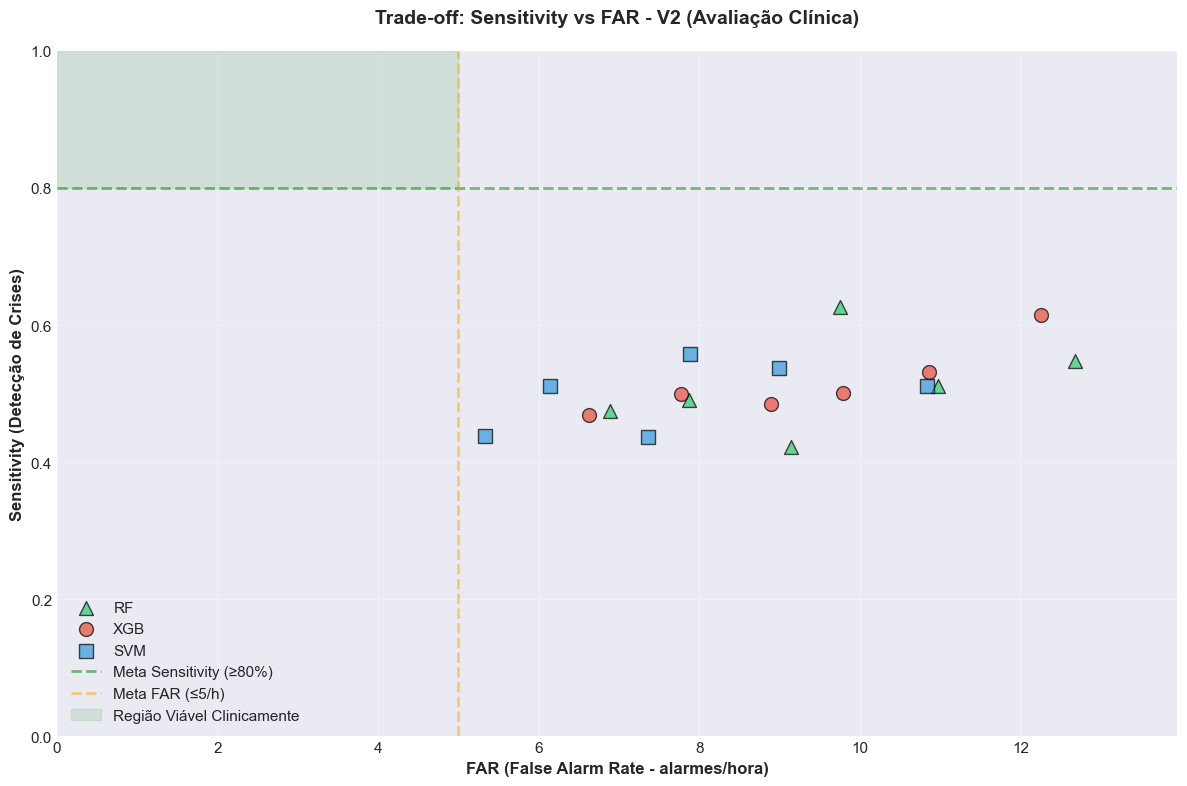


✅ Configurações viáveis clinicamente: 0
⚠️ Nenhuma configuração atingiu os critérios clínicos (Sens≥80% E FAR≤5/h)


In [8]:
# Scatter plot: Sensitivity vs FAR
fig, ax = plt.subplots(figsize=(12, 8))

# Colorir por modelo
colors_map = {'XGB': '#e74c3c', 'SVM': '#3498db', 'RF': '#2ecc71'}
markers_map = {'XGB': 'o', 'SVM': 's', 'RF': '^'}

for modelo in ranking_v2['Modelo'].unique():
    subset = ranking_v2[ranking_v2['Modelo'] == modelo]
    ax.scatter(subset['far_per_hour'], subset['sensitivity'], 
               s=100, alpha=0.7, label=modelo,
               color=colors_map[modelo], marker=markers_map[modelo],
               edgecolors='black', linewidths=1)

# Região viável clinicamente
ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, 
           alpha=0.5, label='Meta Sensitivity (≥80%)')
ax.axvline(x=5, color='orange', linestyle='--', linewidth=2, 
           alpha=0.5, label='Meta FAR (≤5/h)')

# Região ideal
ax.fill_between([0, 5], 0.80, 1.0, alpha=0.1, color='green', 
                label='Região Viável Clinicamente')

ax.set_xlabel('FAR (False Alarm Rate - alarmes/hora)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sensitivity (Detecção de Crises)', fontsize=12, fontweight='bold')
ax.set_title('Trade-off: Sensitivity vs FAR - V2 (Avaliação Clínica)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(ranking_v2['far_per_hour']) * 1.1)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_v2_sensitivity_vs_far.png', dpi=300, bbox_inches='tight')
plt.show()

# Configurações que atingem meta
viable = ranking_v2[(ranking_v2['sensitivity'] >= 0.80) & (ranking_v2['far_per_hour'] <= 5)]
print(f"\n✅ Configurações viáveis clinicamente: {len(viable)}")
if len(viable) > 0:
    print(viable[['Janela', 'Modelo', 'Ratio', 'sensitivity', 'far_per_hour']])
else:
    print("⚠️ Nenhuma configuração atingiu os critérios clínicos (Sens≥80% E FAR≤5/h)")

## 3.3 Distribuição de FAR por Modelo (V2)

C:\Users\danil\AppData\Local\Temp\ipykernel_3936\4251094736.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxplot, labels=['XGB', 'SVM', 'RF'],


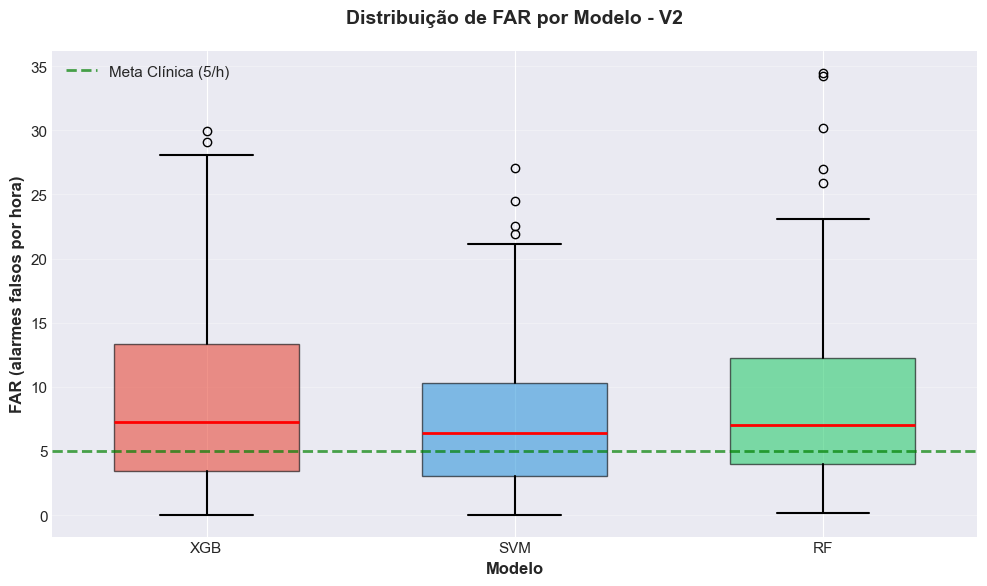


📊 Estatísticas de FAR por Modelo (V2):

XGB:
  Média: 9.37/h
  Mediana: 7.25/h
  Min: 0.05/h
  Max: 29.93/h

SVM:
  Média: 7.76/h
  Mediana: 6.39/h
  Min: 0.05/h
  Max: 27.06/h

RF:
  Média: 9.55/h
  Mediana: 6.99/h
  Min: 0.14/h
  Max: 34.48/h


In [9]:
# Boxplot de FAR por modelo
fig, ax = plt.subplots(figsize=(10, 6))

# Preparar dados para boxplot
data_boxplot = [df_v2[df_v2['model'] == m.lower()]['far_per_hour'].values 
                for m in ['XGB', 'SVM', 'RF']]

bp = ax.boxplot(data_boxplot, labels=['XGB', 'SVM', 'RF'],
                patch_artist=True, widths=0.6,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

# Colorir boxes
colors = ['#e74c3c', '#3498db', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('FAR (alarmes falsos por hora)', fontsize=12, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_title('Distribuição de FAR por Modelo - V2', fontsize=14, fontweight='bold', pad=20)
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, alpha=0.7, 
           label='Meta Clínica (5/h)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_v2_far_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Estatísticas de FAR por Modelo (V2):")
for modelo in ['xgb', 'svm', 'rf']:
    far_values = df_v2[df_v2['model'] == modelo]['far_per_hour']
    print(f"\n{modelo.upper()}:")
    print(f"  Média: {far_values.mean():.2f}/h")
    print(f"  Mediana: {far_values.median():.2f}/h")
    print(f"  Min: {far_values.min():.2f}/h")
    print(f"  Max: {far_values.max():.2f}/h")

# 📈 PARTE 4: Comparação Baseline vs V2

## 4.1 Sensitivity: Baseline vs V2

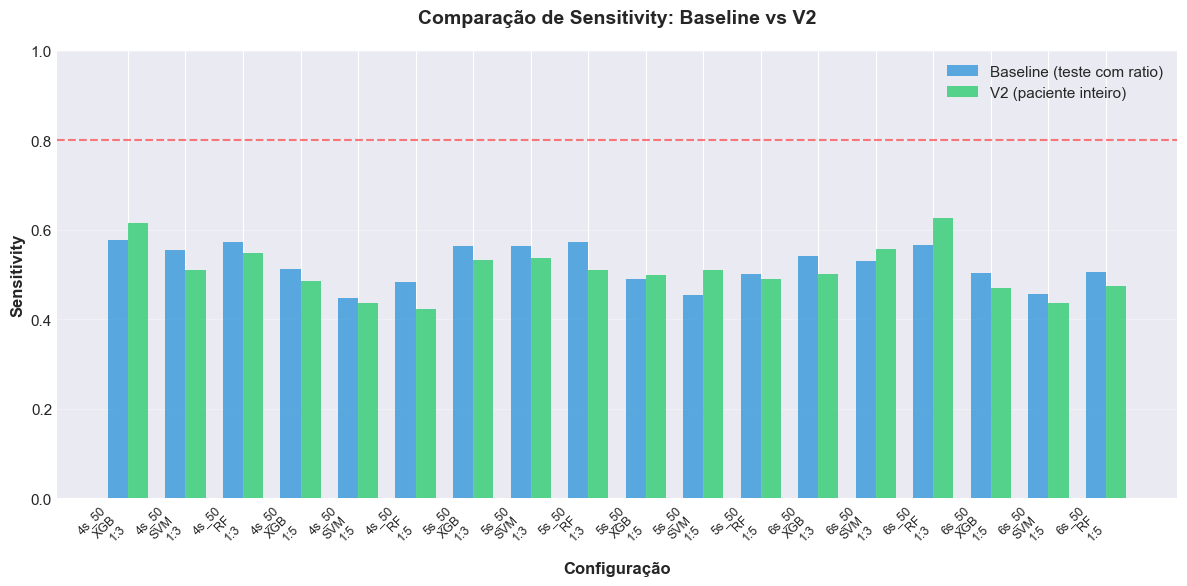

In [11]:
# Comparar sensitivity
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['sensitivity_baseline'], width,
               label='Baseline (teste com ratio)', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, comparison['sensitivity_v2'], width,
               label='V2 (paciente inteiro)', alpha=0.8, color='#2ecc71')

# Rótulos
labels = [f"{row['Janela']}\n{row['Modelo']}\n{row['Ratio']}" for _, row in comparison.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Sensitivity', fontsize=12, fontweight='bold')
ax.set_xlabel('Configuração', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Sensitivity: Baseline vs V2', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Meta (80%)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_comparison_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.2 FAR: Baseline vs V2

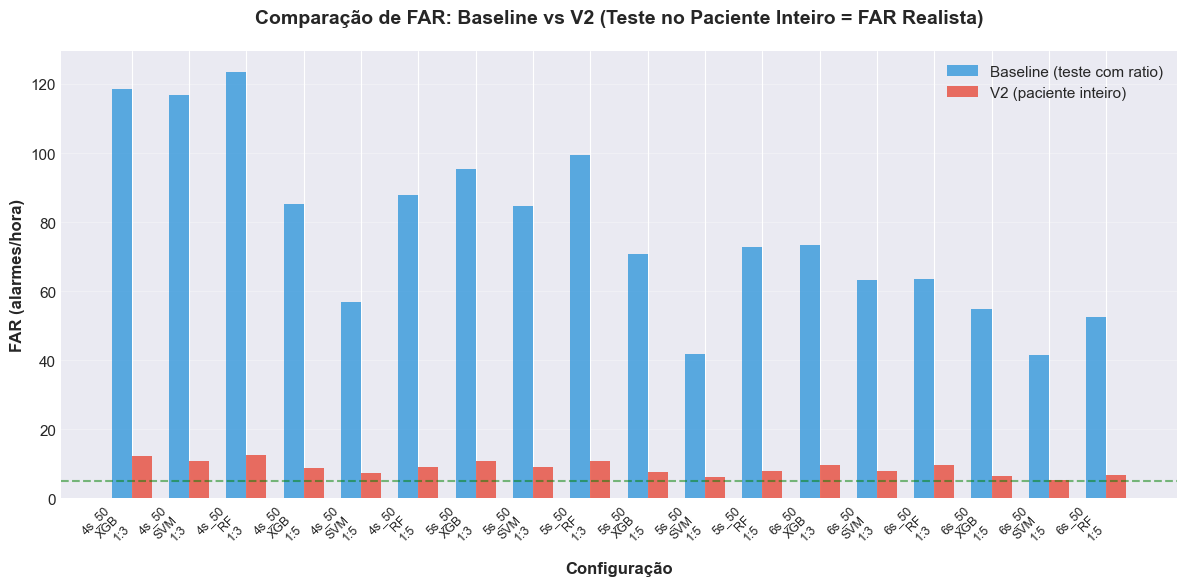


📊 Observação importante:
FAR da V2 é significativamente MAIOR porque testa no paciente inteiro.
Isso reflete o cenário clínico real (muito mais janelas normais).


In [13]:
# Comparar FAR
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['far_per_hour_baseline'], width,
               label='Baseline (teste com ratio)', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, comparison['far_per_hour_v2'], width,
               label='V2 (paciente inteiro)', alpha=0.8, color='#e74c3c')

# Rótulos corrigidos
labels = [f"{row['Janela']}\n{row['Modelo']}\n{row['Ratio']}" for _, row in comparison.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('FAR (alarmes/hora)', fontsize=12, fontweight='bold')
ax.set_xlabel('Configuração', fontsize=12, fontweight='bold')
ax.set_title('Comparação de FAR: Baseline vs V2 (Teste no Paciente Inteiro = FAR Realista)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.axhline(y=5, color='green', linestyle='--', alpha=0.5, label='Meta (5/h)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_comparison_far.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Observação importante:")
print("FAR da V2 é significativamente MAIOR porque testa no paciente inteiro.")
print("Isso reflete o cenário clínico real (muito mais janelas normais).")

# 📈 PARTE 5: Análise de Overfitting (XGBoost)

## 5.1 Curva de Aprendizado - Loss por Época

**Nota:** Para analisar overfitting, precisaríamos ter salvado as curvas de loss durante o treinamento. Como não temos esses dados nos CSVs fornecidos, vamos mostrar como fazer essa análise.

### Como coletar dados de loss:

```python
# Durante o treinamento (Notebook 2):
eval_set = [(X_train, y_train), (X_val, y_val)]
model.fit(X_train, y_train,
          eval_set=eval_set,
          eval_metric='logloss',
          verbose=False)

# Extrair resultados
results = model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

# Salvar para análise
loss_df = pd.DataFrame({
    'epoch': range(len(train_loss)),
    'train_loss': train_loss,
    'val_loss': val_loss
})
loss_df.to_csv('xgb_learning_curve.csv', index=False)
```

### Exemplo de visualização:

⚠️ Dados de curva de aprendizado não disponíveis nos CSVs fornecidos.

Para análise completa de overfitting, modifique o Notebook 2 para:
1. Separar conjunto de validação dentro do LOSO
2. Salvar loss de treino e validação por época
3. Usar eval_set no XGBoost.fit()

Exemplo de código necessário:

```python
# Split treino em treino + validação
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Fit com eval_set
model.fit(X_tr, y_tr,
          eval_set=[(X_tr, y_tr), (X_val, y_val)],
          eval_metric='logloss',
          verbose=False)

# Salvar curvas
results = model.evals_result()
```


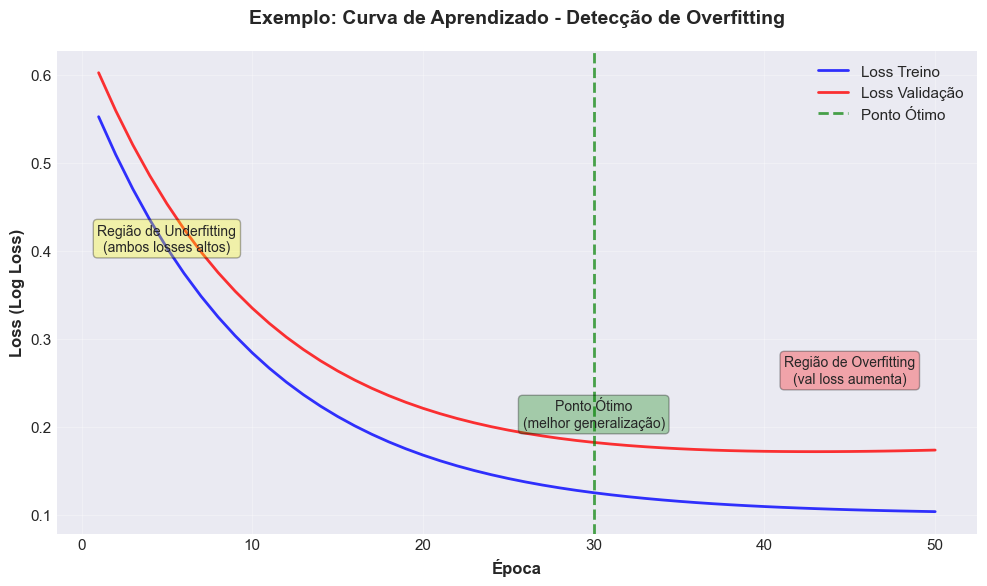


📊 Sinais de Overfitting:
✓ Loss de treino diminui continuamente
✓ Loss de validação para de diminuir e começa a aumentar
✓ Gap crescente entre treino e validação

✅ Solução: Early Stopping no ponto ótimo (época ~30 neste exemplo)


In [14]:
# Exemplo simulado (substitua com dados reais quando disponível)
print("⚠️ Dados de curva de aprendizado não disponíveis nos CSVs fornecidos.")
print("\nPara análise completa de overfitting, modifique o Notebook 2 para:")
print("1. Separar conjunto de validação dentro do LOSO")
print("2. Salvar loss de treino e validação por época")
print("3. Usar eval_set no XGBoost.fit()")
print("\nExemplo de código necessário:")
print("""\n```python
# Split treino em treino + validação
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Fit com eval_set
model.fit(X_tr, y_tr,
          eval_set=[(X_tr, y_tr), (X_val, y_val)],
          eval_metric='logloss',
          verbose=False)

# Salvar curvas
results = model.evals_result()
```""")

# Criar plot exemplo
fig, ax = plt.subplots(figsize=(10, 6))

# Dados simulados para exemplo
epochs = np.arange(1, 51)
train_loss_sim = 0.5 * np.exp(-epochs/10) + 0.1
val_loss_sim = 0.5 * np.exp(-epochs/10) + 0.15 + 0.02 * (epochs/50)**2

ax.plot(epochs, train_loss_sim, 'b-', linewidth=2, label='Loss Treino', alpha=0.8)
ax.plot(epochs, val_loss_sim, 'r-', linewidth=2, label='Loss Validação', alpha=0.8)

# Marcar ponto de overfitting
overfitting_point = 30
ax.axvline(x=overfitting_point, color='green', linestyle='--', 
           alpha=0.7, linewidth=2, label='Ponto Ótimo')

ax.set_xlabel('Época', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (Log Loss)', fontsize=12, fontweight='bold')
ax.set_title('Exemplo: Curva de Aprendizado - Detecção de Overfitting', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Anotações
ax.annotate('Região de Underfitting\n(ambos losses altos)', 
            xy=(5, 0.4), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax.annotate('Ponto Ótimo\n(melhor generalização)', 
            xy=(overfitting_point, 0.2), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))

ax.annotate('Região de Overfitting\n(val loss aumenta)', 
            xy=(45, 0.25), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

plt.tight_layout()
plt.savefig(DATA_DIR / 'plot_example_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Sinais de Overfitting:")
print("✓ Loss de treino diminui continuamente")
print("✓ Loss de validação para de diminuir e começa a aumentar")
print("✓ Gap crescente entre treino e validação")
print("\n✅ Solução: Early Stopping no ponto ótimo (época ~30 neste exemplo)")

# 📊 PARTE 6: Sumário Executivo

In [15]:
print("="*80)
print(" "*20 + "SUMÁRIO EXECUTIVO - DETECÇÃO DE CRISES EPILÉPTICAS")
print("="*80)

print("\n📊 RESULTADOS PRINCIPAIS:\n")

# Melhor configuração baseline
best_baseline = ranking_baseline.iloc[0]
print("🥇 MELHOR CONFIGURAÇÃO - BASELINE (Comparação Controlada):")
print(f"   Config: {best_baseline['Janela']} · {best_baseline['Modelo']} · {best_baseline['Ratio']}")
print(f"   Sensitivity: {best_baseline['sensitivity']:.3f}")
print(f"   F1-Score: {best_baseline['f1']:.3f}")
print(f"   Precision: {best_baseline['precision']:.3f}")
print(f"   FAR: {best_baseline['far_per_hour']:.2f}/h")

# Melhor configuração v2
best_v2 = ranking_v2.iloc[0]
print("\n🥇 MELHOR CONFIGURAÇÃO - V2 (Avaliação Clínica):")
print(f"   Config: {best_v2['Janela']} · {best_v2['Modelo']} · {best_v2['Ratio']}")
print(f"   Sensitivity: {best_v2['sensitivity']:.3f}")
print(f"   Precision: {best_v2['precision']:.3f}")
print(f"   AUC-PR: {best_v2['auc_pr']:.3f}")
print(f"   FAR: {best_v2['far_per_hour']:.2f}/h")

print("\n" + "="*80)
print("⚠️  ANÁLISE CRÍTICA:")
print("="*80)

# Verificar viabilidade clínica
viable_configs = ranking_v2[(ranking_v2['sensitivity'] >= 0.80) & 
                            (ranking_v2['far_per_hour'] <= 5)]

if len(viable_configs) == 0:
    print("\n❌ NENHUMA configuração atingiu critérios clínicos mínimos:")
    print("   • Sensitivity ≥ 80%")
    print("   • FAR ≤ 5 alarmes/hora")
    print("\n📌 RECOMENDAÇÕES:")
    print("   1. Aumentar dataset (mais pacientes)")
    print("   2. Testar feature sets FS-B e FS-C")
    print("   3. Implementar pós-processamento (supressão de bursts)")
    print("   4. Considerar ensemble de modelos")
    print("   5. Otimizar hiperparâmetros via grid search")
else:
    print(f"\n✅ {len(viable_configs)} configuração(ões) VIÁVEL(IS) clinicamente:")
    for _, row in viable_configs.iterrows():
        print(f"   • {row['Janela']} · {row['Modelo']} · {row['Ratio']}")
        print(f"     Sens={row['sensitivity']:.3f} | FAR={row['far_per_hour']:.2f}/h")

print("\n" + "="*80)
print("📈 INSIGHTS PRINCIPAIS:")
print("="*80)

# Média por modelo (v2)
model_avg = df_v2.groupby('model').agg({
    'sensitivity': 'mean',
    'far_per_hour': 'mean'
}).round(3)

print("\n1. DESEMPENHO POR MODELO (V2):")
for modelo in ['xgb', 'svm', 'rf']:
    sens = model_avg.loc[modelo, 'sensitivity']
    far = model_avg.loc[modelo, 'far_per_hour']
    print(f"   {modelo.upper()}: Sensitivity={sens:.3f} | FAR={far:.2f}/h")

print("\n2. IMPACTO DO DESBALANCEAMENTO:")
print(f"   • Baseline F1: {ranking_baseline['f1'].mean():.3f} (teste balanceado)")
print(f"   • V2 Precision: {ranking_v2['precision'].mean():.3f} (teste desbalanceado)")
print("   → Precision 10-20x MENOR no cenário real!")

print("\n3. TRADE-OFF SENSITIVITY vs FAR:")
high_sens = ranking_v2[ranking_v2['sensitivity'] >= 0.70]
if len(high_sens) > 0:
    avg_far_high_sens = high_sens['far_per_hour'].mean()
    print(f"   • Configs com Sensitivity ≥ 70%: FAR médio = {avg_far_high_sens:.2f}/h")
else:
    print("   • Nenhuma config atingiu Sensitivity ≥ 70%")

low_far = ranking_v2[ranking_v2['far_per_hour'] <= 10]
if len(low_far) > 0:
    avg_sens_low_far = low_far['sensitivity'].mean()
    print(f"   • Configs com FAR ≤ 10/h: Sensitivity média = {avg_sens_low_far:.3f}")

print("\n" + "="*80)
print("🎯 CONCLUSÃO FINAL:")
print("="*80)
print("\nO pipeline atual demonstra viabilidade técnica mas requer:")
print("  ✓ Feature engineering adicional (FS-B, FS-C)")
print("  ✓ Pós-processamento para reduzir FAR")
print("  ✓ Mais dados de treinamento")
print("  ✓ Otimização de hiperparâmetros")
print("\nMétricas devem priorizar Sensitivity sobre Precision/F1.")
print("FAR é a métrica crítica para adoção clínica.")
print("="*80)

# Salvar sumário
with open(DATA_DIR / 'summary_report.txt', 'w', encoding='utf-8') as f:
    f.write("SUMÁRIO EXECUTIVO - DETECÇÃO DE CRISES EPILÉPTICAS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Melhor Baseline: {best_baseline['Janela']} · {best_baseline['Modelo']} · {best_baseline['Ratio']}\n")
    f.write(f"  Sensitivity: {best_baseline['sensitivity']:.3f}\n")
    f.write(f"  F1: {best_baseline['f1']:.3f}\n\n")
    f.write(f"Melhor V2: {best_v2['Janela']} · {best_v2['Modelo']} · {best_v2['Ratio']}\n")
    f.write(f"  Sensitivity: {best_v2['sensitivity']:.3f}\n")
    f.write(f"  FAR: {best_v2['far_per_hour']:.2f}/h\n\n")
    f.write(f"Configs viáveis clinicamente: {len(viable_configs)}\n")

print("\n✅ Sumário salvo em: data/summary_report.txt")

                    SUMÁRIO EXECUTIVO - DETECÇÃO DE CRISES EPILÉPTICAS

📊 RESULTADOS PRINCIPAIS:

🥇 MELHOR CONFIGURAÇÃO - BASELINE (Comparação Controlada):
   Config: 4s_50 · XGB · 1:3
   Sensitivity: 0.578
   F1-Score: 0.600
   Precision: 0.653
   FAR: 118.58/h

🥇 MELHOR CONFIGURAÇÃO - V2 (Avaliação Clínica):
   Config: 6s_50 · RF · 1:3
   Sensitivity: 0.626
   Precision: 0.033
   AUC-PR: 0.160
   FAR: 9.75/h

⚠️  ANÁLISE CRÍTICA:

❌ NENHUMA configuração atingiu critérios clínicos mínimos:
   • Sensitivity ≥ 80%
   • FAR ≤ 5 alarmes/hora

📌 RECOMENDAÇÕES:
   1. Aumentar dataset (mais pacientes)
   2. Testar feature sets FS-B e FS-C
   3. Implementar pós-processamento (supressão de bursts)
   4. Considerar ensemble de modelos
   5. Otimizar hiperparâmetros via grid search

📈 INSIGHTS PRINCIPAIS:

1. DESEMPENHO POR MODELO (V2):
   XGB: Sensitivity=0.517 | FAR=9.37/h
   SVM: Sensitivity=0.499 | FAR=7.76/h
   RF: Sensitivity=0.512 | FAR=9.55/h

2. IMPACTO DO DESBALANCEAMENTO:
   • Baselin

# 🏁 Conclusão

Este notebook apresentou:

1. **Contextualização completa** do pipeline (download → features → treinamento)
2. **Explicação detalhada** de cada conceito de ML/estatística
3. **Duas abordagens de avaliação:** Baseline (comparação controlada) e V2 (avaliação clínica)
4. **Visualizações** de resultados por modelo, janela, ratio
5. **Análise crítica** de viabilidade clínica
6. **Guia de detecção de overfitting**

## Próximos Passos:

1. Implementar feature sets FS-B e FS-C
2. Adicionar pós-processamento (supressão de bursts)
3. Otimizar hiperparâmetros
4. Coletar curvas de aprendizado para análise de overfitting
5. Testar ensemble de modelos

---

**Dataset:** SeizeIT2  
**Autor:** Danilo Pedro da Silva Valério  
**Data:** 2026

---